## 17. Optimización de hiperparámetros con Manifold Mixup

In [1]:
import torch
import numpy as np

TARGET_SR = 16_000
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
RANDOM_STATE = 42
N_FOLDS = 5
TEST_SIZE = 0.0

%load_ext autoreload
%autoreload 2

print(f"Device: {DEVICE}")

Device: mps


In [2]:
from src.preprocessing import load_waveforms, preprocess_waveform, load_metadata
from sklearn.model_selection import train_test_split

df_metadata = load_metadata(base_path="data")
waveforms_raw, df_metadata = load_waveforms(df_metadata, target_sr=TARGET_SR)
waveforms_processed = [preprocess_waveform(wf) for wf in waveforms_raw]

labels_all = df_metadata["label"].to_numpy()

if TEST_SIZE > 0:
    train_idx, test_idx = train_test_split(
        np.arange(len(labels_all)),
        test_size=TEST_SIZE,
        stratify=labels_all,
        random_state=RANDOM_STATE,
    )
else:
    train_idx = np.arange(len(labels_all))
    test_idx = np.array([], dtype=int)

print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")
print(f"Train PD={labels_all[train_idx].sum():.0f}, HC={len(train_idx) - labels_all[train_idx].sum():.0f}")

/Users/napster/Documents/upm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 100 | Test: 0
Train PD=50, HC=50


In [4]:
from src.embeddings import extract_multilayer_embeddings
from src.spectral import extract_spectral_features
from sklearn.preprocessing import StandardScaler

waveforms_all = [waveforms_processed[i] for i in train_idx] + [waveforms_processed[i] for i in test_idx]

w2v_layers = extract_multilayer_embeddings(waveforms_all, "facebook/wav2vec2-base", [0], DEVICE)
emb_w2v_L0 = w2v_layers[0]

MEL_CONFIG = {"sample_rate": TARGET_SR, "n_fft": 1024, "hop_length": 512, "n_mels": 128}
spectral_features = extract_spectral_features(waveforms_all, device=DEVICE, **MEL_CONFIG)

n_train = len(train_idx)

scaler_t = StandardScaler()
scaler_s = StandardScaler()

emb_t_train = scaler_t.fit_transform(emb_w2v_L0[:n_train])
emb_s_train = scaler_s.fit_transform(spectral_features[:n_train])

if TEST_SIZE > 0:
    emb_t_test = scaler_t.transform(emb_w2v_L0[n_train:])
    emb_s_test = scaler_s.transform(spectral_features[n_train:])
else:
    emb_t_test = np.array([])
    emb_s_test = np.array([])

labels_train = labels_all[train_idx]
labels_test = labels_all[test_idx] if TEST_SIZE > 0 else np.array([])

print(f"Embeddings: train={len(emb_t_train)}, test={len(emb_t_test)}")

2026-04-12 23:03:45,628 [INFO] src.config:   Cargando facebook/wav2vec2-base...
2026-04-12 23:03:46,098 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-12 23:03:46,202 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-04-12 23:03:46,383 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-04-12 23:03:46,587 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-12 23:03:46,756 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-04-12 23:03:46,946 [INFO] httpx: HTTP Request: HEAD https://huggingfac

  25/100
  50/100
  75/100


2026-04-12 23:03:49,794 [INFO] src.config: Generando mel-espectrogramas...
2026-04-12 23:03:49,846 [INFO] src.config:   100 espectrogramas generados
2026-04-12 23:03:49,847 [INFO] src.config:   Shape ejemplo: (128, 107)
2026-04-12 23:03:49,847 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...


  100/100


2026-04-12 23:03:50,098 [INFO] src.config:   25/100
2026-04-12 23:03:50,167 [INFO] src.config:   50/100
2026-04-12 23:03:50,234 [INFO] src.config:   75/100
2026-04-12 23:03:50,303 [INFO] src.config:   100/100
2026-04-12 23:03:50,303 [INFO] src.config:   Features espectrales: (100, 512)


Embeddings: train=100, test=0


In [5]:
def manifold_mixup_intraclass(emb_t, emb_s, labels, alpha, rng):
    aug_t, aug_s, aug_labels = [], [], []

    for cls in [0, 1]:
        cls_idx = np.where(labels == cls)[0]
        if len(cls_idx) < 2:
            continue
        for i in cls_idx:
            j = rng.choice(cls_idx[cls_idx != i])
            lam = rng.beta(alpha, alpha)
            aug_t.append(lam * emb_t[i] + (1 - lam) * emb_t[j])
            aug_s.append(lam * emb_s[i] + (1 - lam) * emb_s[j])
            aug_labels.append(cls)

    return np.array(aug_t), np.array(aug_s), np.array(aug_labels)

### Búsqueda de hiperparámetros con Optuna

Se optimizan los hiperparámetros del modelo **junto con** el α del Manifold Mixup.

In [6]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from src.datasets import DualBranchDataset
from src.training import train_fold_regularized

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.15, step=0.025)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    dim_proj = trial.suggest_categorical("dim_proj", [64, 128])
    dim_hidden = trial.suggest_categorical("dim_hidden", [64, 128])
    mixup_alpha = trial.suggest_float("mixup_alpha", 0.1, 1.0, step=0.1)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_aucs = []

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_train, labels_train)):
        tr_emb_t, tr_emb_s = emb_t_train[tr_idx], emb_s_train[tr_idx]
        tr_labels = labels_train[tr_idx]

        rng = np.random.default_rng(RANDOM_STATE + fold_idx)
        aug_t, aug_s, aug_labels = manifold_mixup_intraclass(
            tr_emb_t, tr_emb_s, tr_labels, mixup_alpha, rng
        )

        tr_emb_t_aug = np.concatenate([tr_emb_t, aug_t])
        tr_emb_s_aug = np.concatenate([tr_emb_s, aug_s])
        tr_labels_aug = np.concatenate([tr_labels, aug_labels])

        train_ds = DualBranchDataset(tr_emb_t_aug, tr_emb_s_aug, tr_labels_aug, np.arange(len(tr_labels_aug)))
        val_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx)

        y_true, y_prob, _, _ = train_fold_regularized(
            train_ds, val_ds, DEVICE,
            lr=lr, weight_decay=weight_decay, dropout=dropout,
            label_smoothing=label_smoothing, batch_size=batch_size,
            dim_proj=dim_proj, dim_hidden=dim_hidden,
            epochs=120, patience=20,
            scheduler_factor=0.5, scheduler_patience=7,
        )

        fold_aucs.append(roc_auc_score(y_true, y_prob))

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    trial.set_user_attr("auc_mean", mean_auc)
    trial.set_user_attr("auc_std", std_auc)

    return mean_auc - 0.5 * std_auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=120, show_progress_bar=True)

Best trial: 69. Best value: 0.877208: 100%|██████████| 120/120 [10:02<00:00,  5.02s/it]


In [7]:
best = study.best_trial
print(f"Mejor trial #{best.number}")
print(f"  Score (AUC - 0.5*std): {best.value:.4f}")
print(f"  AUC: {best.user_attrs['auc_mean']:.3f} ± {best.user_attrs['auc_std']:.3f}")
print(f"  Parámetros:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

Mejor trial #69
  Score (AUC - 0.5*std): 0.8772
  AUC: 0.918 ± 0.082
  Parámetros:
    lr: 0.0005346595817189126
    weight_decay: 0.0020935871682685654
    dropout: 0.30000000000000004
    label_smoothing: 0.1
    batch_size: 16
    dim_proj: 64
    dim_hidden: 64
    mixup_alpha: 0.7000000000000001


### Búsqueda de hiperparámetros con Gaussian Noise

In [10]:
from src.embeddings import extract_multilayer_embeddings
from src.spectral import extract_spectral_features


def augment_waveform_noise(waveform, snr_db, rng):
    power_signal = np.mean(waveform ** 2)
    power_noise = power_signal / (10 ** (snr_db / 10))
    return waveform + rng.normal(0, np.sqrt(power_noise), size=waveform.shape)


def build_augmented_features(train_idx, snr_db, rng):
    waveforms_aug = []
    for idx in train_idx:
        waveforms_aug.append(augment_waveform_noise(waveforms_processed[idx], snr_db, rng))

    # Sin test cuando TEST_SIZE=0
    if TEST_SIZE > 0:
        waveforms_all = (
            [waveforms_processed[i] for i in train_idx]
            + waveforms_aug
            + [waveforms_processed[i] for i in test_idx]
        )
    else:
        waveforms_all = (
            [waveforms_processed[i] for i in train_idx]
            + waveforms_aug
        )

    w2v = extract_multilayer_embeddings(waveforms_all, "facebook/wav2vec2-base", [0], DEVICE)[0]
    spec = extract_spectral_features(waveforms_all, device=DEVICE, **MEL_CONFIG)

    n_tr = len(train_idx)
    n_aug = len(waveforms_aug)

    sc_t, sc_s = StandardScaler(), StandardScaler()
    emb_t_tr = sc_t.fit_transform(w2v[:n_tr + n_aug])
    emb_s_tr = sc_s.fit_transform(spec[:n_tr + n_aug])

    if TEST_SIZE > 0:
        emb_t_te = sc_t.transform(w2v[n_tr + n_aug:])
        emb_s_te = sc_s.transform(spec[n_tr + n_aug:])
    else:
        emb_t_te = np.array([])
        emb_s_te = np.array([])

    labels_tr = np.concatenate([labels_all[train_idx], labels_all[train_idx]])

    return emb_t_tr, emb_s_tr, labels_tr, emb_t_te, emb_s_te, n_tr

In [11]:
# Pre-computar embeddings para SNR candidatos
SNR_OPTIONS = [15, 20, 25, 30]
precomputed = {}

for snr in SNR_OPTIONS:
    print(f"Pre-computando embeddings para SNR={snr} dB...")
    rng = np.random.default_rng(RANDOM_STATE)
    precomputed[snr] = build_augmented_features(train_idx, snr, rng)

print("Listo.")

2026-04-12 23:14:53,165 [INFO] src.config:   Cargando facebook/wav2vec2-base...


Pre-computando embeddings para SNR=15 dB...


2026-04-12 23:14:53,543 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-12 23:14:53,643 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-04-12 23:14:53,820 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-04-12 23:14:53,992 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-04-12 23:14:54,170 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-04-12 23:14:54,354 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Fou

  25/200
  50/200
  75/200
  100/200
  125/200
  150/200
  175/200


2026-04-12 23:14:59,367 [INFO] src.config: Generando mel-espectrogramas...
2026-04-12 23:14:59,461 [INFO] src.config:   200 espectrogramas generados
2026-04-12 23:14:59,461 [INFO] src.config:   Shape ejemplo: (128, 107)
2026-04-12 23:14:59,462 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...


...

  25/200
  50/200
  75/200
  100/200
  125/200
  150/200
  175/200


2026-04-12 23:15:19,057 [INFO] src.config: Generando mel-espectrogramas...
2026-04-12 23:15:19,144 [INFO] src.config:   200 espectrogramas generados
2026-04-12 23:15:19,144 [INFO] src.config:   Shape ejemplo: (128, 107)
2026-04-12 23:15:19,144 [INFO] src.config: Extrayendo features con ResNet18 (ImageNet)...


  200/200


2026-04-12 23:15:19,334 [INFO] src.config:   25/200
2026-04-12 23:15:19,397 [INFO] src.config:   50/200
2026-04-12 23:15:19,458 [INFO] src.config:   75/200
2026-04-12 23:15:19,518 [INFO] src.config:   100/200
2026-04-12 23:15:19,579 [INFO] src.config:   125/200
2026-04-12 23:15:19,639 [INFO] src.config:   150/200
2026-04-12 23:15:19,700 [INFO] src.config:   175/200
2026-04-12 23:15:19,760 [INFO] src.config:   200/200
2026-04-12 23:15:19,760 [INFO] src.config:   Features espectrales: (200, 512)


Listo.


### Busqueda con Optuna para Gaussian Noise

In [12]:
def objective_noise(trial):
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.05)
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.15, step=0.025)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    dim_proj = trial.suggest_categorical("dim_proj", [64, 128])
    dim_hidden = trial.suggest_categorical("dim_hidden", [64, 128])
    snr_db = trial.suggest_categorical("snr_db", SNR_OPTIONS)

    emb_t_tr, emb_s_tr, labels_tr, _, _, n_tr = precomputed[snr_db]

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_aucs = []

    # Labels originales para split (solo primeros n_tr)
    labels_orig = labels_tr[:n_tr]

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_tr[:n_tr], labels_orig)):
        # Train: originales del fold + sus augmentadas (mismo índice + n_tr)
        tr_idx_aug = np.concatenate([tr_idx, tr_idx + n_tr])
        labels_fold = labels_tr[tr_idx_aug]

        train_ds = DualBranchDataset(emb_t_tr, emb_s_tr, labels_tr, tr_idx_aug)
        val_ds = DualBranchDataset(emb_t_tr, emb_s_tr, labels_tr, val_idx)

        y_true, y_prob, _, _ = train_fold_regularized(
            train_ds, val_ds, DEVICE,
            lr=lr, weight_decay=weight_decay, dropout=dropout,
            label_smoothing=label_smoothing, batch_size=batch_size,
            dim_proj=dim_proj, dim_hidden=dim_hidden,
            epochs=120, patience=20,
            scheduler_factor=0.5, scheduler_patience=7,
        )

        fold_aucs.append(roc_auc_score(y_true, y_prob))

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    trial.set_user_attr("auc_mean", mean_auc)
    trial.set_user_attr("auc_std", std_auc)

    return mean_auc - 0.5 * std_auc


study_noise = optuna.create_study(direction="maximize")
study_noise.optimize(objective_noise, n_trials=60, show_progress_bar=True)

Best trial: 37. Best value: 0.838563: 100%|██████████| 60/60 [05:11<00:00,  5.19s/it]


### Evaluación con mejores hiperparámetros

In [14]:
from sklearn.metrics import accuracy_score, recall_score, roc_curve

bp = study.best_params
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_aucs, fold_accs, fold_sens, fold_spec = [], [], [], []

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(emb_t_train, labels_train)):
    tr_emb_t, tr_emb_s = emb_t_train[tr_idx], emb_s_train[tr_idx]
    tr_labels = labels_train[tr_idx]

    rng = np.random.default_rng(RANDOM_STATE + fold_idx)
    aug_t, aug_s, aug_labels = manifold_mixup_intraclass(
        tr_emb_t, tr_emb_s, tr_labels, bp["mixup_alpha"], rng
    )

    tr_emb_t_aug = np.concatenate([tr_emb_t, aug_t])
    tr_emb_s_aug = np.concatenate([tr_emb_s, aug_s])
    tr_labels_aug = np.concatenate([tr_labels, aug_labels])

    train_ds = DualBranchDataset(tr_emb_t_aug, tr_emb_s_aug, tr_labels_aug, np.arange(len(tr_labels_aug)))
    val_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, val_idx)

    y_true, y_prob, _, _ = train_fold_regularized(
        train_ds, val_ds, DEVICE,
        lr=bp["lr"], weight_decay=bp["weight_decay"],
        dropout=bp["dropout"], label_smoothing=bp["label_smoothing"],
        batch_size=bp["batch_size"], dim_proj=bp["dim_proj"],
        dim_hidden=bp["dim_hidden"], epochs=120, patience=20,
        scheduler_factor=0.5, scheduler_patience=7,
    )

    auc = roc_auc_score(y_true, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]

    fold_aucs.append(auc)
    fold_accs.append(acc)
    fold_sens.append(sens)
    fold_spec.append(spec)

    print(f"Fold {fold_idx+1}: AUC={auc:.3f} | Acc={acc:.3f} | Sens={sens:.3f} | Spec={spec:.3f}")

print(f"\nCV Mixup Optimizado: AUC={np.mean(fold_aucs):.3f}±{np.std(fold_aucs):.3f} | "
      f"Acc={np.mean(fold_accs):.3f}±{np.std(fold_accs):.3f} | "
      f"Sens={np.mean(fold_sens):.3f}±{np.std(fold_sens):.3f} | "
      f"Spec={np.mean(fold_spec):.3f}±{np.std(fold_spec):.3f}")

Fold 1: AUC=0.980 | Acc=0.900 | Sens=0.800 | Spec=0.900
Fold 2: AUC=0.760 | Acc=0.650 | Sens=0.800 | Spec=0.900
Fold 3: AUC=0.820 | Acc=0.800 | Sens=0.600 | Spec=1.000
Fold 4: AUC=1.000 | Acc=0.950 | Sens=0.900 | Spec=1.000
Fold 5: AUC=0.960 | Acc=0.850 | Sens=0.700 | Spec=1.000

CV Mixup Optimizado: AUC=0.904±0.096 | Acc=0.830±0.103 | Sens=0.760±0.102 | Spec=0.960±0.049


### Test holdout: Baseline vs. Mixup optimizado

In [15]:
import matplotlib.pyplot as plt

N_SEEDS = 5

def compute_metrics(y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]
    return auc, acc, sens, spec

# === BASELINE ===
bl_probs = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, np.arange(len(labels_train)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, _ = train_fold_regularized(
        train_ds, test_ds, DEVICE,
        lr=bp["lr"], weight_decay=bp["weight_decay"],
        dropout=bp["dropout"], label_smoothing=bp["label_smoothing"],
        batch_size=bp["batch_size"], dim_proj=bp["dim_proj"],
        dim_hidden=bp["dim_hidden"], epochs=120, patience=20,
        scheduler_factor=0.5, scheduler_patience=7,
    )
    bl_probs.append(y_prob)

bl_prob = np.mean(bl_probs, axis=0)
bl_pred = (bl_prob >= 0.5).astype(int)
bl_m = compute_metrics(y_true, bl_prob, bl_pred)

# === MANIFOLD MIXUP OPTIMIZADO ===
rng_mm = np.random.default_rng(RANDOM_STATE)
aug_t, aug_s, aug_lab = manifold_mixup_intraclass(emb_t_train, emb_s_train, labels_train, bp["mixup_alpha"], rng_mm)

emb_t_mm = np.concatenate([emb_t_train, aug_t])
emb_s_mm = np.concatenate([emb_s_train, aug_s])
labels_mm = np.concatenate([labels_train, aug_lab])

mm_probs = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_mm, emb_s_mm, labels_mm, np.arange(len(labels_mm)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, _ = train_fold_regularized(
        train_ds, test_ds, DEVICE,
        lr=bp["lr"], weight_decay=bp["weight_decay"],
        dropout=bp["dropout"], label_smoothing=bp["label_smoothing"],
        batch_size=bp["batch_size"], dim_proj=bp["dim_proj"],
        dim_hidden=bp["dim_hidden"], epochs=120, patience=20,
        scheduler_factor=0.5, scheduler_patience=7,
    )
    mm_probs.append(y_prob)

mm_prob = np.mean(mm_probs, axis=0)
mm_pred = (mm_prob >= 0.5).astype(int)
mm_m = compute_metrics(y_true, mm_prob, mm_pred)

# === TABLA ===
print("=" * 60)
print("Test Holdout (ensemble 5 seeds)")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>10} {'Mixup Opt':>10} {'Δ':>10}")
print(f"  {'─' * 45}")
for name, bl, mm in zip(["AUC", "Accuracy", "Sensibilidad", "Especificidad"], bl_m, mm_m):
    print(f"  {name:<15} {bl:>10.3f} {mm:>10.3f} {mm - bl:>+10.3f}")

ValueError: batch_size should be a positive integer value, but got batch_size=0

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, recall_score
import matplotlib.pyplot as plt

def compute_metrics(y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]
    return auc, acc, sens, spec

# === GAUSSIAN NOISE OPTIMIZADO ===
bp_n = study_noise.best_params
snr_opt = bp_n["snr_db"]
emb_t_tr_n, emb_s_tr_n, labels_tr_n, emb_t_te_n, emb_s_te_n, n_tr_n = precomputed[snr_opt]

gn_probs = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_tr_n, emb_s_tr_n, labels_tr_n, np.arange(len(labels_tr_n)))
    test_ds = DualBranchDataset(emb_t_te_n, emb_s_te_n, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, _ = train_fold_regularized(
        train_ds, test_ds, DEVICE,
        lr=bp_n["lr"], weight_decay=bp_n["weight_decay"],
        dropout=bp_n["dropout"], label_smoothing=bp_n["label_smoothing"],
        batch_size=bp_n["batch_size"], dim_proj=bp_n["dim_proj"],
        dim_hidden=bp_n["dim_hidden"], epochs=120, patience=20,
        scheduler_factor=0.5, scheduler_patience=7,
    )
    gn_probs.append(y_prob)

gn_prob = np.mean(gn_probs, axis=0)
gn_pred = (gn_prob >= 0.5).astype(int)
gn_m = compute_metrics(y_true, gn_prob, gn_pred)

# Recalcular bl_m y mm_m con la misma función local
bl_m = compute_metrics(y_true, bl_prob, bl_pred)
mm_m = compute_metrics(y_true, mm_prob, mm_pred)

# === TABLA 3 MODELOS ===
print("=" * 70)
print("Test Holdout (ensemble 5 seeds)")
print("=" * 70)
print(f"  {'Métrica':<15} {'Baseline':>10} {'Mixup Opt':>10} {'Noise Opt':>10}")
print(f"  {'─' * 55}")
for name, bl, mm, gn in zip(["AUC", "Accuracy", "Sensibilidad", "Especificidad"], bl_m, mm_m, gn_m):
    print(f"  {name:<15} {bl:>10.3f} {mm:>10.3f} {gn:>10.3f}")

# === GRÁFICOS 3 MODELOS ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
x = np.arange(4); width = 0.25
ax.bar(x - width, bl_m, width, label="Baseline", color="#2196F3", alpha=0.8)
ax.bar(x, mm_m, width, label="Mixup Opt", color="#9C27B0", alpha=0.8)
ax.bar(x + width, gn_m, width, label="Noise Opt", color="#4CAF50", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(["AUC", "Acc", "Sens", "Spec"])
ax.set_ylim(0, 1.15); ax.set_ylabel("Score"); ax.legend()
ax.set_title("Test Holdout: 3 modelos")

ax = axes[1]
fpr_bl, tpr_bl, _ = roc_curve(y_true, bl_prob)
fpr_mm, tpr_mm, _ = roc_curve(y_true, mm_prob)
fpr_gn, tpr_gn, _ = roc_curve(y_true, gn_prob)
ax.plot(fpr_bl, tpr_bl, color="#2196F3", linewidth=2, label=f"Baseline ({bl_m[0]:.3f})")
ax.plot(fpr_mm, tpr_mm, color="#9C27B0", linewidth=2, label=f"Mixup Opt ({mm_m[0]:.3f})")
ax.plot(fpr_gn, tpr_gn, color="#4CAF50", linewidth=2, label=f"Noise Opt ({gn_m[0]:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("1 - Especificidad"); ax.set_ylabel("Sensibilidad")
ax.set_title("Curvas ROC"); ax.legend()

ax = axes[2]
ax.hist(mm_prob[y_true == 0], bins=10, alpha=0.4, color="#9C27B0", label="HC (Mixup)")
ax.hist(mm_prob[y_true == 1], bins=10, alpha=0.4, color="#FF9800", label="PD (Mixup)")
ax.hist(gn_prob[y_true == 0], bins=10, alpha=0.3, edgecolor="#4CAF50", linewidth=2, histtype="step", label="HC (Noise)")
ax.hist(gn_prob[y_true == 1], bins=10, alpha=0.3, edgecolor="#F44336", linewidth=2, histtype="step", label="PD (Noise)")
ax.set_xlabel("P(PD)"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de probabilidades"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

ValueError: batch_size should be a positive integer value, but got batch_size=0

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, recall_score

N_SEEDS = 5
mixup_alpha = bp["mixup_alpha"]
bp_model = {k: v for k, v in bp.items() if k != "mixup_alpha"}

def compute_metrics(y_true, y_prob, y_pred):
    auc = roc_auc_score(y_true, y_prob)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    spec = 1 - fpr[np.argmax(tpr - fpr)]
    return auc, acc, sens, spec

# === BASELINE ===
bl_probs, bl_histories = [], []
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_train, emb_s_train, labels_train, np.arange(len(labels_train)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, hist = train_fold_regularized(train_ds, test_ds, DEVICE, **bp_model)
    bl_probs.append(y_prob)
    bl_histories.append(hist)

bl_prob = np.mean(bl_probs, axis=0)
bl_pred = (bl_prob >= 0.5).astype(int)
bl_m = compute_metrics(y_true, bl_prob, bl_pred)

# === MIXUP OPTIMIZADO ===
rng_mm = np.random.default_rng(RANDOM_STATE)
aug_t, aug_s, aug_l = manifold_mixup_intraclass(emb_t_train, emb_s_train, labels_train, mixup_alpha, rng_mm)
emb_t_mm = np.concatenate([emb_t_train, aug_t])
emb_s_mm = np.concatenate([emb_s_train, aug_s])
labels_mm = np.concatenate([labels_train, aug_l])

mm_probs, mm_histories = [], []
for seed in range(N_SEEDS):
    torch.manual_seed(seed); np.random.seed(seed)
    train_ds = DualBranchDataset(emb_t_mm, emb_s_mm, labels_mm, np.arange(len(labels_mm)))
    test_ds = DualBranchDataset(emb_t_test, emb_s_test, labels_test, np.arange(len(labels_test)))
    y_true, y_prob, _, hist = train_fold_regularized(train_ds, test_ds, DEVICE, **bp_model)
    mm_probs.append(y_prob)
    mm_histories.append(hist)

mm_prob = np.mean(mm_probs, axis=0)
mm_pred = (mm_prob >= 0.5).astype(int)
mm_m = compute_metrics(y_true, mm_prob, mm_pred)

# === TABLA ===
print("=" * 60)
print("Test Holdout (ensemble 5 seeds)")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>10} {'Mixup Opt':>10} {'Δ':>10}")
print(f"  {'─' * 45}")
for name, bl, mm in zip(["AUC", "Accuracy", "Sensibilidad", "Especificidad"], bl_m, mm_m):
    print(f"  {name:<15} {bl:>10.3f} {mm:>10.3f} {mm - bl:>+10.3f}")

ValueError: batch_size should be a positive integer value, but got batch_size=0

NameError: name 'mm_histories' is not defined

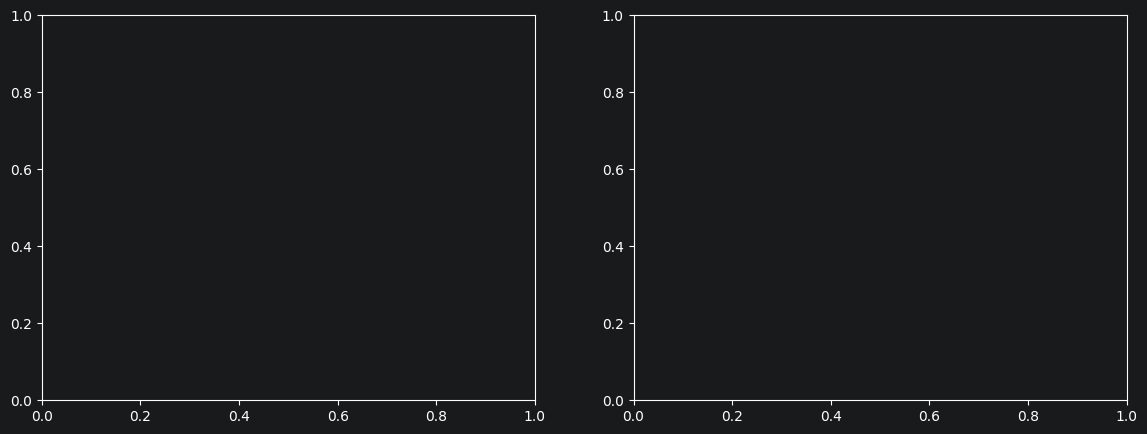

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ["Baseline", "Manifold Mixup"]
all_hist = [bl_histories, mm_histories]
colors_train = ["#2196F3", "#9C27B0"]
colors_val = ["#F44336", "#E91E63"]

for ax, title, histories, ct, cv in zip(axes, titles, all_hist, colors_train, colors_val):
    for seed, hist in enumerate(histories):
        epochs = range(1, len(hist["train_loss"]) + 1)
        alpha = 0.3 if seed > 0 else 1.0
        label_tr = "Train" if seed == 0 else None
        label_val = "Val" if seed == 0 else None
        ax.plot(epochs, hist["train_loss"], color=ct, alpha=alpha, linewidth=1, label=label_tr)
        ax.plot(epochs, hist["val_loss"], color=cv, alpha=alpha, linewidth=1, label=label_val)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.suptitle("Curvas de pérdida — Train vs. Val (5 seeds)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
def cv_pearson(values):
    return (np.std(values) / np.mean(values)) * 100 if np.mean(values) != 0 else 0

def metrics_per_seed(probs_list, y_true):
    aucs, accs, senss, specs = [], [], [], []
    for y_prob in probs_list:
        y_pred = (y_prob >= 0.5).astype(int)
        aucs.append(roc_auc_score(y_true, y_prob))
        accs.append(accuracy_score(y_true, y_pred))
        senss.append(recall_score(y_true, y_pred, pos_label=1))
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        specs.append(1 - fpr[np.argmax(tpr - fpr)])
    return aucs, accs, senss, specs

bl_seeds = metrics_per_seed(bl_probs, y_true)
mm_seeds = metrics_per_seed(mm_probs, y_true)

print("=" * 60)
print("Coeficiente de Variación de Pearson (CV%) — 5 seeds")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>12} {'Mixup Opt':>12}")
print(f"  {'─' * 39}")
for name, bl_s, mm_s in zip(
    ["AUC", "Accuracy", "Sensibilidad", "Especificidad"],
    bl_seeds, mm_seeds
):
    print(f"  {name:<15} {cv_pearson(bl_s):>11.2f}% {cv_pearson(mm_s):>11.2f}%")

print(f"\n{'=' * 60}")
print("Media ± Std por seed")
print("=" * 60)
print(f"  {'Métrica':<15} {'Baseline':>16} {'Mixup Opt':>16}")
print(f"  {'─' * 47}")
for name, bl_s, mm_s in zip(
    ["AUC", "Accuracy", "Sensibilidad", "Especificidad"],
    bl_seeds, mm_seeds
):
    print(f"  {name:<15} {np.mean(bl_s):.3f}±{np.std(bl_s):.3f}  "
          f"{np.mean(mm_s):.3f}±{np.std(mm_s):.3f}")

NameError: name 'mm_probs' is not defined